# JPEG Warehouse CytoDataFrame Demo

This notebook opens `../database.jpg`, attaches the embedded DuckDB database,
and explores it. Every row here is real: `cellprofiler.nuclei`/`cells`/
`cytoplasm`/`ph3` are real CellProfiler-equivalent measurements (via
`cp_measure`) of a real, CC-0-licensed CellProfiler `ExampleHuman` microscopy
field, and `cellprofiler.single_cell` merges them the same way CytoTable's
own preset does. `images.object_crops` holds real per-object crops of that
field: each row is a self-describing OME-Arrow-style record (it carries the
source field's own `size_c`/`size_z`/`size_y`/`size_x` and `source`/
`source_url` alongside its own `tile_y`/`tile_x`/`height`/`width`), with the
pixel data stored three ways -- `pixel_data_raw` (uncompressed array bytes,
queryable with no decoding), `pixel_data_jpegxl` (compact JPEG XL), and
`pixel_data_jpeg` (plain JPEG). `morphem.features` holds one real, fixed-size
deep-learning embedding per real cell, from the real, pretrained
[CaicedoLab/MorphEm](https://huggingface.co/CaicedoLab/MorphEm) model. See
`tools/real_example_data` for how they were all produced.

In [1]:
import tempfile
from pathlib import Path

import pandas as pd
import pillow_jxl  # noqa: F401  (registers JPEG XL support in Pillow)

from picture_thousand_records import build_artifacts, connect_to_warehouse

warehouse_path = Path("..") / "database.jpg"
if not warehouse_path.exists():
    build_artifacts(Path(".."))

extract_dir = Path(tempfile.mkdtemp(prefix="jpeg-warehouse-notebook-"))
attached = connect_to_warehouse(warehouse_path, temp_dir=extract_dir)
con = attached.connection
attached.mode

'zipfs'

In [2]:
from cytodataframe import CytoDataFrame

profiles = con.sql("""
SELECT
    ObjectNumber,
    AreaShape_Area,
    AreaShape_Eccentricity,
    AreaShape_Perimeter,
    Intensity_MeanIntensity_DNA,
    Intensity_MeanIntensity_PH3,
    Parent_Nuclei
FROM warehouse.cellprofiler.cells
ORDER BY ObjectNumber
""").df()

cdf = CytoDataFrame(profiles)
cdf.head()

,ObjectNumber,AreaShape_Area,AreaShape_Eccentricity,AreaShape_Perimeter,Intensity_MeanIntensity_DNA,Intensity_MeanIntensity_PH3,Parent_Nuclei
0,1,273.0,0.481305,63.834524,0.080083,0.039201,1
1,2,211.0,0.564957,56.627417,0.114302,0.039569,2
2,3,483.0,0.448903,83.698485,0.071855,0.039597,5
3,4,113.0,0.972224,54.727922,0.038626,0.039355,7
4,5,743.0,0.936105,149.539105,0.077597,0.039464,11


ObjectNumber,image
1,
2,
3,
4,
5,
6,
7,
8,
9,
10,

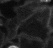
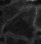

In [3]:
import base64

from IPython.display import HTML
from IPython.display import display as show

crop_df = con.sql("""
SELECT ObjectNumber, pixel_data_jpeg
FROM warehouse.images.object_crops
WHERE object_type = 'cells' AND channel = 'cellbody'
ORDER BY ObjectNumber
LIMIT 12
""").df()


def jpeg_to_data_url(jpeg_bytes: bytes) -> str:
    # pixel_data_jpeg is already a real, plain JPEG -- no decoding needed,
    # just base64 it straight into an <img> tag.
    encoded = base64.b64encode(jpeg_bytes).decode("ascii")
    return f'<img src="data:image/jpeg;base64,{encoded}" width="96">'


display_df = crop_df.assign(image=crop_df["pixel_data_jpeg"]).drop(
    columns=["pixel_data_jpeg"],
)
html = display_df.to_html(
    escape=False,
    formatters={"image": jpeg_to_data_url},
    index=False,
)
show(HTML(html))

In [4]:
cdf_image_rows = con.sql("""
SELECT
    c.ObjectNumber AS Metadata_ObjectNumber,
    ROUND(c.AreaShape_Area, 2) AS Feature_AreaShape_Area,
    oc.pixel_data_jpeg
FROM warehouse.cellprofiler.cells c
JOIN warehouse.images.object_crops oc
    ON oc.ObjectNumber = c.ObjectNumber AND oc.object_type = 'cells'
WHERE oc.channel = 'cellbody'
ORDER BY c.ObjectNumber
LIMIT 8
""").df()

cdf_image_dir = Path(tempfile.mkdtemp(prefix="jpeg-warehouse-cdf-images-"))
cdf_records = []
for _, row in cdf_image_rows.iterrows():
    file_name = f"object_{row['Metadata_ObjectNumber']}.jpg"
    # pixel_data_jpeg is already a real JPEG, so it's written straight to
    # disk with no decode/re-encode round trip.
    (cdf_image_dir / file_name).write_bytes(row["pixel_data_jpeg"])
    cdf_records.append(
        {
            "Metadata_ObjectNumber": int(row["Metadata_ObjectNumber"]),
            "Feature_AreaShape_Area": float(row["Feature_AreaShape_Area"]),
            "Image_FileName_DNA": file_name,
        }
    )

image_cdf = CytoDataFrame(
    pd.DataFrame(cdf_records),
    data_context_dir=str(cdf_image_dir),
    display_options={"render_whole_image": True, "width": "120"},
)
image_cdf[
    [
        "Metadata_ObjectNumber",
        "Feature_AreaShape_Area",
        "Image_FileName_DNA",
    ]
]

,Metadata_ObjectNumber,Feature_AreaShape_Area,Image_FileName_DNA
0,1,273.0,object_1.jpg
1,2,211.0,object_2.jpg
2,3,483.0,object_3.jpg
3,4,113.0,object_4.jpg
4,5,743.0,object_5.jpg
5,6,64.0,object_6.jpg
6,7,521.0,object_7.jpg
7,8,304.0,object_8.jpg


size_c                                                    3
size_z                                                    1
size_y                                                  512
size_x                                                  512
z                                                         0
source    CellProfiler ExampleHuman tutorial dataset (CC-0)
Name: 0, dtype: object


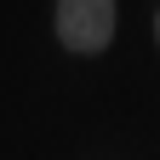

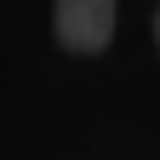

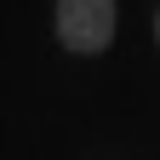

raw vs jpegxl mean abs diff: 0.7938311688311688
raw vs jpeg mean abs diff:   0.5324675324675324


In [5]:
import io

import numpy as np
from PIL import Image

sample_object = con.sql("""
SELECT DISTINCT ObjectNumber
FROM warehouse.images.object_crops
WHERE object_type = 'cells'
ORDER BY ObjectNumber
LIMIT 1
""").fetchone()[0]

record = con.sql(f"""
SELECT *
FROM warehouse.images.object_crops
WHERE object_type = 'cells' AND ObjectNumber = {sample_object} AND channel = 'DNA'
""").df().iloc[0]

# every crop row is a self-describing OME-Arrow-style record: the source
# field's own dimensions/attribution travel with it, no join required
print(record[["size_c", "size_z", "size_y", "size_x", "z", "source"]])

# the same crop, decoded three ways
raw = np.frombuffer(record["pixel_data_raw"], dtype=np.uint8).reshape(
    record["height"], record["width"]
)
jxl = Image.open(io.BytesIO(record["pixel_data_jpegxl"]))
jpg = Image.open(io.BytesIO(record["pixel_data_jpeg"]))

show(
    Image.fromarray(raw).resize((160, 160)),
    jxl.resize((160, 160)),
    jpg.resize((160, 160)),
)
print("raw vs jpegxl mean abs diff:", np.abs(raw.astype(int) - np.array(jxl)).mean())
print("raw vs jpeg mean abs diff:  ", np.abs(raw.astype(int) - np.array(jpg)).mean())

In [6]:
summary = con.sql("""
SELECT
    ObjectNumber,
    ROUND(AreaShape_Area, 2) AS area,
    ROUND(AreaShape_Eccentricity, 3) AS eccentricity,
    ROUND(Intensity_MeanIntensity_DNA, 4) AS mean_dna_intensity,
    ROUND(Intensity_MeanIntensity_PH3, 4) AS mean_ph3_intensity
FROM warehouse.cellprofiler.cells
ORDER BY AreaShape_Area DESC
LIMIT 10
""").df()
summary

,ObjectNumber,area,eccentricity,mean_dna_intensity,mean_ph3_intensity
0,49,1762.0,0.584,0.0650,0.0394
1,35,1214.0,0.527,0.0751,0.0376
2,61,1140.0,0.464,0.0984,0.0405
3,270,1025.0,0.875,0.0745,0.0402
4,36,1017.0,0.844,0.0696,0.0401
5,218,988.0,0.908,0.0699,0.0408
6,79,980.0,0.691,0.0721,0.0388
7,28,936.0,0.823,0.0811,0.0374
8,258,870.0,0.903,0.0737,0.0396
9,89,869.0,0.331,0.0799,0.0402


## CytoTable-style single-cell view

`cellprofiler.single_cell` merges Cytoplasm/Cells/Nuclei into one row per
cell, anchored on Cytoplasm with Cells/Nuclei `LEFT JOIN`ed via
`Parent_Cells`/`Parent_Nuclei` -- the same join CytoTable's own
`cellprofiler_csv` preset uses for this exact dataset.

In [7]:
single_cell = con.sql("""
SELECT
    Cytoplasm_ObjectNumber,
    Cells_ObjectNumber,
    Nuclei_ObjectNumber,
    ROUND(Cells_AreaShape_Area, 2) AS cell_area,
    ROUND(Nuclei_AreaShape_Area, 2) AS nucleus_area,
    ROUND(Nuclei_Intensity_MeanIntensity_DNA, 4) AS nucleus_dna_intensity
FROM warehouse.cellprofiler.single_cell
ORDER BY Cytoplasm_ObjectNumber
LIMIT 10
""").df()
single_cell

,Cytoplasm_ObjectNumber,Cells_ObjectNumber,Nuclei_ObjectNumber,cell_area,nucleus_area,nucleus_dna_intensity
0,1,1,1,273.0,70.0,0.1896
1,2,2,2,211.0,79.0,0.2222
2,3,3,5,483.0,85.0,0.1979
3,4,4,7,113.0,94.0,0.2081
4,5,5,11,743.0,124.0,0.2482
5,6,6,3,64.0,266.0,0.2115
6,7,7,3,521.0,266.0,0.2115
7,8,8,3,304.0,266.0,0.2115
8,9,9,8,422.0,220.0,0.2921
9,10,10,4,458.0,132.0,0.1915


## Real MorphEm embeddings and similarity search

`morphem.features.embedding` is a fixed-size `FLOAT[1152]` array: the real,
pretrained [CaicedoLab/MorphEm](https://huggingface.co/CaicedoLab/MorphEm)
Vision Transformer run independently over each cell's DNA/PH3/cell-body
crop (384-d each), concatenated. `array_distance` finds the real nearest
neighbors of a real cell directly in DuckDB, no extension required.

In [8]:
query_object = con.sql(
    "SELECT ObjectNumber FROM warehouse.morphem.features ORDER BY ObjectNumber LIMIT 1"
).fetchone()[0]

neighbors = con.sql(f"""
SELECT
    f.ObjectNumber,
    array_distance(
        f.embedding,
        (
            SELECT embedding FROM warehouse.morphem.features
            WHERE ObjectNumber = {query_object}
        )
    ) AS distance,
    oc.pixel_data_jpeg
FROM warehouse.morphem.features f
JOIN warehouse.images.object_crops oc
    ON oc.ObjectNumber = f.ObjectNumber
    AND oc.object_type = 'cells'
    AND oc.channel = 'cellbody'
ORDER BY distance
LIMIT 6
""").df()

print(f"cells most similar to cell {query_object} by real MorphEm embedding:")
display_df = neighbors.assign(image=neighbors["pixel_data_jpeg"]).drop(
    columns=["pixel_data_jpeg"],
)
html = display_df.to_html(
    escape=False,
    formatters={"image": jpeg_to_data_url},
    index=False,
)
show(HTML(html))

cells most similar to cell 1 by real MorphEm embedding:


ObjectNumber,distance,image
1,0.000000,
29,39.078999,
2,39.193314,
293,41.102020,
294,41.827362,
110,41.831940,
